In [1]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
#from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

In [3]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [11]:
total_points = sb.shape[0]
t = np.arange(total_points)

In [12]:
limite_marco = 31 * 40
limite_abril = limite_marco + (30 * 40)
limite_marco, limite_abril

(1240, 2440)

In [15]:
future_steps = sb.shape[0] - limite_abril
future_steps

1200

## ETS

In [17]:
with open('results/ETS-short-time-targets.pkl', 'rb') as f:
    ets_targets = pickle.load(f)

## PropHet

In [28]:
with open('results/prophet-short-targets.pkl', 'rb') as f:
    ph_targets = pickle.load(f)

### SARIMA

In [29]:
with open('results/sarima-short-time-targets.pkl', 'rb') as f:
    sarima_targets = pickle.load(f)

### MLP

In [31]:
with open('results/mlp-short-time-targets.pkl', 'rb') as f:
    mlp_targets = pickle.load(f)

## LSTM

In [32]:
with open('results/lstm-short-time-targets.pkl', 'rb') as f:
    lstm_targets = pickle.load(f)

## GRU

In [33]:
with open('results/gru-short-time-targets.pkl', 'rb') as f:
    gru_targets = pickle.load(f)

## Chronos

In [35]:
with open('results/chronos-short-time-targets.pkl', 'rb') as f:
    chr_targets = pickle.load(f)

## TimesFs 200

In [40]:
with open('results/timesfm-1.0-200m-pytorch-targets-short.pkl', 'rb') as f:
    ts200_targets = pickle.load(f)

## TimesFS 500

In [41]:
with open('results/timesfm-2.0-500m-pytorch-targets-short.pkl', 'rb') as f:
    ts500_targets = pickle.load(f)

## Plot train and test

In [21]:
nodes = list(ets_targets.keys())

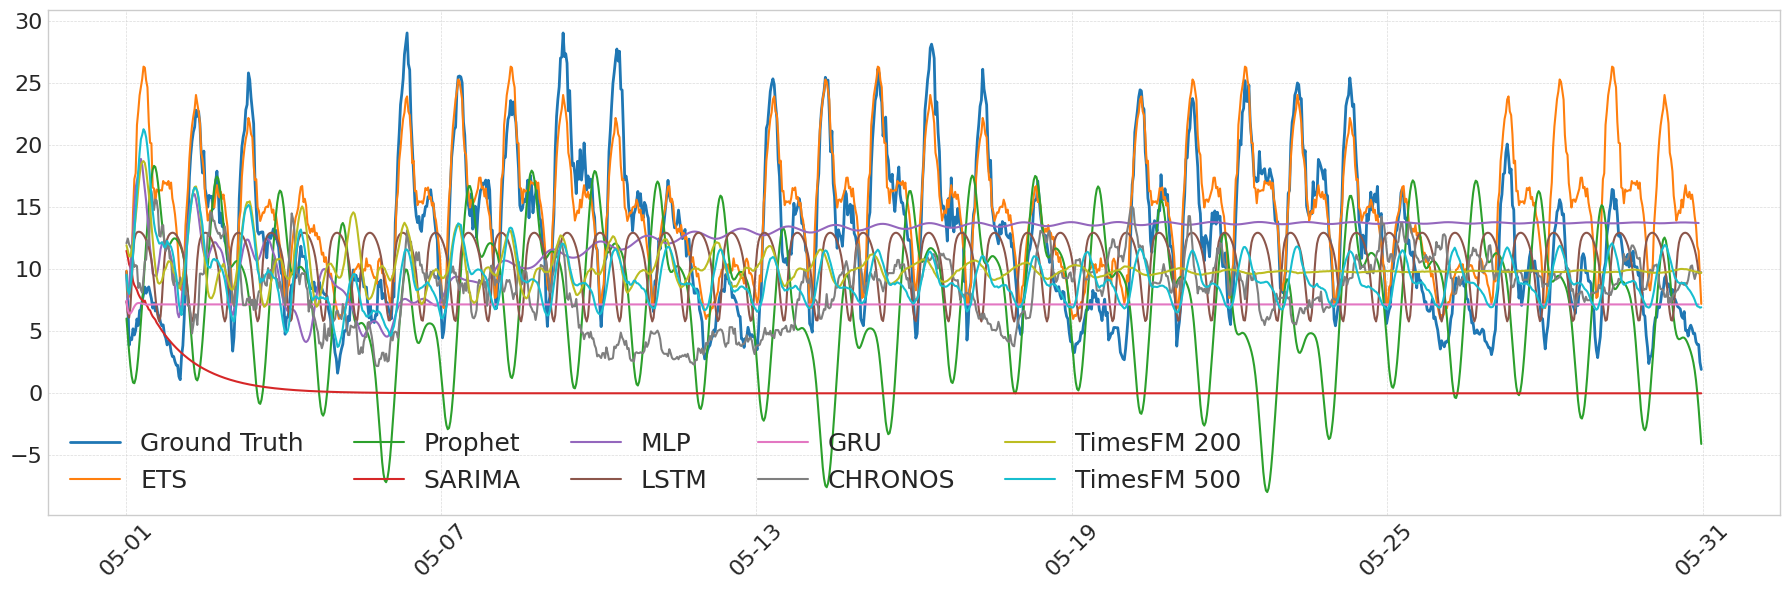

In [46]:
### Plot All
batch_idx = 0

node = nodes[batch_idx]
node_ts_ph = ph_targets[node]
node_ts_ets = ets_targets[node]
node_ts_sarima = sarima_targets[node]

node_ts_mlp = mlp_targets[node]
node_ts_lstm = lstm_targets[node]
node_ts_gru = gru_targets[node]
node_ts_chronos = chr_targets[node]
node_ts_200 = ts200_targets[node][0]
node_ts_500 = ts500_targets[node][0]



forecast_index = range(len(node_ts_ets["input"]), 
                       len(node_ts_ets["input"]) + node_ts_ets["true"].shape[0])


plt.figure(figsize=(18,6))
# Traçar as curvas com espessura apropriada
plt.plot(forecast_index, node_ts_ets["true"], linewidth=2.0,  label="Ground Truth")#color='gray',
plt.plot(forecast_index, node_ts_ets["pred"], linewidth=1.5, label="ETS")
plt.plot(forecast_index, node_ts_ph["pred"], linewidth=1.5, label="Prophet")
plt.plot(forecast_index, node_ts_sarima["pred"], linewidth=1.5, label="SARIMA")
plt.plot(forecast_index[:-2], node_ts_mlp["pred"], linewidth=1.5, label="MLP")
plt.plot(forecast_index[:-2], node_ts_lstm["pred"], linewidth=1.5, label="LSTM")
plt.plot(forecast_index[:-2], node_ts_gru["pred"], linewidth=1.5, label="GRU")
plt.plot(forecast_index, node_ts_chronos["pred"], linewidth=1.5, label="CHRONOS")#color='k',
plt.plot(forecast_index, node_ts_200["pred"], linewidth=1.5, label="TimesFM 200")
plt.plot(forecast_index, node_ts_500["pred"], linewidth=1.5, label="TimesFM 500")

# Eixos e títulos
plt.xlabel("", fontsize=14)
plt.ylabel("", fontsize=14)
#plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks=valores, labels=datas, fontsize=16, rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=18, loc='lower left', frameon=False, ncol=5)

# Layout compacto
plt.tight_layout()
plt.savefig("forecast_short.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [23]:
forecast_index

range(2438, 3640)

In [ ]:
forecast_index

In [25]:
start_date = "2024-05-01"
end_date = "2024-05-31"

datas = pd.date_range(start=start_date, end=end_date, periods=6)
datas = ['05-01', 
         '05-07', 
         '05-13', 
         '05-19',
         '05-25', 
         '05-31']

In [26]:
valores = np.linspace(2438, 3640, num=6, dtype=int)
print(valores.tolist())

[2438, 2678, 2918, 3159, 3399, 3640]
